#  Create a heatmap of missing values (if applicable) using a manually constructed grid, mapping missing data points with custom color gradients instead of using Seaborn or Matplotlib heatmap functions.

In [1]:
import csv

with open("heart.csv", "r", encoding="utf-8") as file:

    reader = csv.reader(file)

    rows = list(reader)

columns = rows[0]
data = rows[1:]

print("Rows:", len(data))
print("Columns:", len(columns))

Rows: 918
Columns: 12


# Missing value manually check

In [2]:
missing_count = 0

for row in data:

    for value in row:

        if value.strip() == "":
            missing_count += 1

print("Total missing values:", missing_count)

Total missing values: 0


# Missing Grid

In [3]:
missing_grid = []

for row in data:

    row_grid = []

    for value in row:

        if value.strip() == "":
            row_grid.append(1)
        else:
            row_grid.append(0)

    missing_grid.append(row_grid)

print(missing_grid[:5])

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]


In [4]:
column_missing = {}

for i in range(len(columns)):

    count = 0

    for row in missing_grid:

        if row[i] == 1:
            count += 1

    column_missing[columns[i]] = count

print(column_missing)

{'Age': 0, 'Sex': 0, 'ChestPainType': 0, 'RestingBP': 0, 'Cholesterol': 0, 'FastingBS': 0, 'RestingECG': 0, 'MaxHR': 0, 'ExerciseAngina': 0, 'Oldpeak': 0, 'ST_Slope': 0, 'HeartDisease': 0}


# Missing columns

In [5]:
missing_columns = []

for column in columns:

    if column_missing[column] > 0:

        missing_columns.append(column)

print("Columns with missing values:")
print(missing_columns)

Columns with missing values:
[]


# Missing Values

In [6]:
if len(missing_columns) == 0:

    print(
        "No missing values found in the dataset."
    )

No missing values found in the dataset.


In [7]:
if len(missing_columns) > 0:

    selected_indexes = []

    for column in missing_columns:

        selected_indexes.append(
            columns.index(column)
        )

    selected_grid = []

    for row in missing_grid:

        new_row = []

        for index in selected_indexes:

            new_row.append(row[index])

        selected_grid.append(new_row)

    print(selected_grid[:5])

# Matplotlib

In [8]:
import matplotlib.pyplot as plt

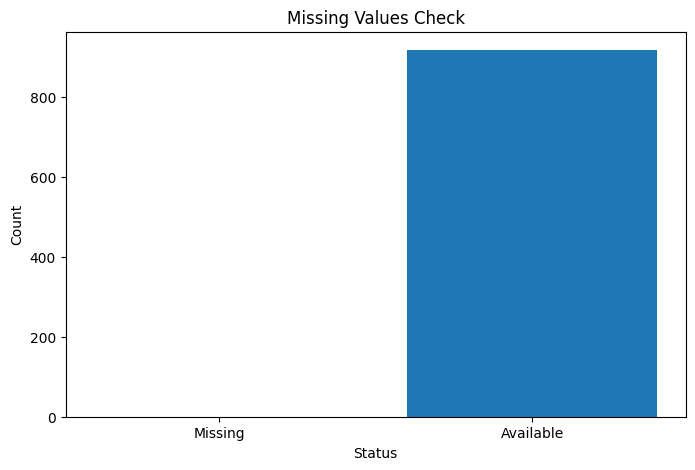

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    ["Missing", "Available"],
    [0, len(data)]
)

plt.title("Missing Values Check")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()